# MalariaCell MLOps — Model Evaluation Notebook

This notebook builds and evaluates the compact CNN used by the MalariaCell deployment.

**Dataset:** NIH Malaria Cell Images

Optimization techniques used:
- BatchNormalization + Dropout regularization
- Adam optimizer + ReduceLROnPlateau
- EarlyStopping
- Retraining with a frozen convolutional backbone and trainable classification head

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import MODEL_PATH, TEST_DIR, TRAIN_DIR
from src.model import build_malaria_cnn, configure_tf_memory, get_callbacks, save_model
from src.preprocessing import create_splits, dataset_counts, download_dataset
from src.retrain import make_tf_dataset_from_directory

import numpy as np
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

configure_tf_memory()
print('ROOT', ROOT)
print('MODEL_PATH', MODEL_PATH)

2026-07-29 18:35:13.610993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 18:35:13.677926: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-29 18:35:13.740269: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785339313.805468   18909 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785339313.838681   18909 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-29 18:35:13.983191: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

ROOT /home/berissa/Documents/Machine-Learning-OP
MODEL_PATH /home/berissa/Documents/Machine-Learning-OP/models/malaria_cnn.keras


2026-07-29 18:35:17.116374: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 1. Data acquisition

In [2]:
source = download_dataset(force=False)
create_splits(source_dir=source, max_per_class=1500, rebuild=False)
print('Train counts:', dataset_counts(TRAIN_DIR))
print('Test counts:', dataset_counts(TEST_DIR))

Train counts: {'Parasitized': 1600, 'Uninfected': 1600, 'total': 3200}
Test counts: {'Parasitized': 400, 'Uninfected': 400, 'total': 800}


## 2. Data processing

Found 3200 files belonging to 2 classes.
Found 800 files belonging to 2 classes.
Batch shape: (32, 128, 128, 3) labels: [[0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]]


2026-07-29 18:35:59.922759: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
/tmp/ipykernel_18909/1689662198.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(y[i].numpy()))


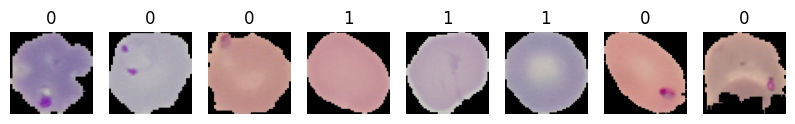

2026-07-29 18:36:00.142718: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
train_ds = make_tf_dataset_from_directory(TRAIN_DIR, shuffle=True).cache().prefetch(1)
test_ds = make_tf_dataset_from_directory(TEST_DIR, shuffle=False).cache().prefetch(1)

for x, y in train_ds.take(1):
    print('Batch shape:', x.shape, 'labels:', y.numpy()[:8])
    plt.figure(figsize=(10, 3))
    for i in range(8):
        plt.subplot(1, 8, i + 1)
        plt.imshow(x[i].numpy())
        plt.axis('off')
        plt.title(int(y[i].numpy()))
    plt.show()

## 3. Model creation

In [4]:
model = build_malaria_cnn()
model.summary()

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=8,
    callbacks=get_callbacks(MODEL_PATH),
)
save_model(model, MODEL_PATH)

Model: "malaria_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,561 (431.88 KB)

 Trainable params: 110,113 (430.13 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/8


2026-07-29 18:36:10.879903: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.
2026-07-29 18:36:10.961723: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.
2026-07-29 18:36:10.992757: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 67108864 exceeds 10% of free system memory.
2026-07-29 18:36:11.048951: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.
2026-07-29 18:36:11.070061: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 33554432 exceeds 10% of free system memory.


100/100 ━━━━━━━━━━━━━━━━━━━━ 71s 686ms/step - accuracy: 0.6612 - auc: 0.7103 - loss: 0.6291 - precision: 0.6530 - recall: 0.6881 - val_accuracy: 0.5000 - val_auc: 0.6771 - val_loss: 0.9639 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 648ms/step - accuracy: 0.7806 - auc: 0.8476 - loss: 0.5082 - precision: 0.7598 - recall: 0.8206 - val_accuracy: 0.5013 - val_auc: 0.9010 - val_loss: 1.1814 - val_precision: 0.5006 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 649ms/step - accuracy: 0.8625 - auc: 0.9220 - loss: 0.3788 - precision: 0.8388 - recall: 0.8975 - val_accuracy: 0.5063 - val_auc: 0.8772 - val_loss: 1.1987 - val_precision: 0.5032 - val_recall: 0.9975 - learning_rate: 0.0010
Epoch 4/8
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 649ms/step - accuracy: 0.8953 - auc: 0.9443 - loss: 0.3106 - precision: 0.8772 - recall: 0.9194 - val_accuracy: 0.5825 - val_auc: 0.9290 - val_loss: 1.1062 - val_p

PosixPath('/home/berissa/Documents/Machine-Learning-OP/models/malaria_cnn.keras')

## 4. Model testing — at least 4 metrics

In [5]:
y_true, y_prob = [], []
for batch_x, batch_y in test_ds:
    probs = model.predict(batch_x, verbose=0).ravel()
    y_prob.extend(probs.tolist())
    y_true.extend(batch_y.numpy().ravel().tolist())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

metrics = {
    'accuracy': float(accuracy_score(y_true, y_pred)),
    'precision': float(precision_score(y_true, y_pred, zero_division=0)),
    'recall': float(recall_score(y_true, y_pred, zero_division=0)),
    'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    'auc': float(roc_auc_score(y_true, y_prob)),
    'loss': float(history.history['loss'][-1]),
}
print(metrics)
print(classification_report(y_true, y_pred, target_names=['Parasitized', 'Uninfected']))

{'accuracy': 0.925, 'precision': 0.8811659192825112, 'recall': 0.9825, 'f1': 0.9290780141843972, 'auc': 0.97651875, 'loss': 0.20816481113433838}
              precision    recall  f1-score   support

 Parasitized       0.98      0.87      0.92       400
  Uninfected       0.88      0.98      0.93       400

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.92       800
weighted avg       0.93      0.93      0.92       800



2026-07-29 18:52:59.043897: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


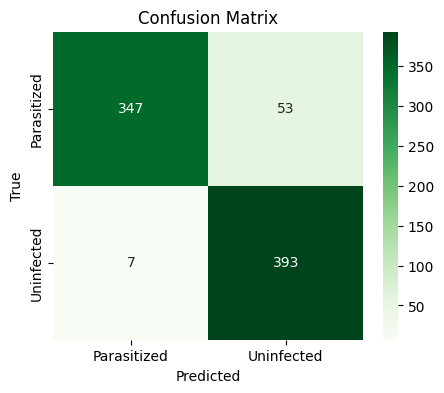

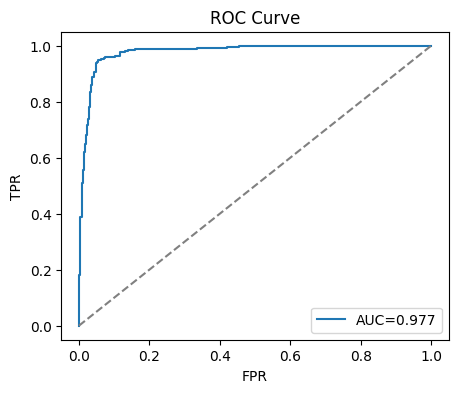

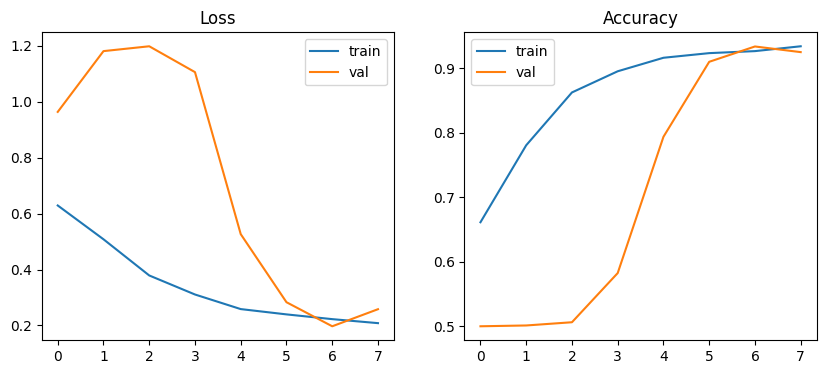

In [6]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Parasitized', 'Uninfected'],
            yticklabels=['Parasitized', 'Uninfected'])
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC={metrics['auc']:.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()
plt.show()

hist = history.history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='train')
plt.plot(hist['val_loss'], label='val')
plt.title('Loss'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='train')
plt.plot(hist['val_accuracy'], label='val')
plt.title('Accuracy'); plt.legend()
plt.show()

## 5. Deployment note

After training, save `models/malaria_cnn.keras` and deploy the API with Docker.
Retraining in the web UI freezes convolutional layers and fine-tunes the dense head on user-uploaded images stored in SQLite and `data/uploads/`.